# Cheese Analysis: Classifying Cheese Fat Levels

#### Report By: Bismark Addo Amoako(ID:0867880)

**Introduction:** Cheese lovers, manufacturers, and nutrition experts might all ponder: “Can we predict whether a cheese is ‘higher fat’ or ‘lower fat’ based on its features?” This question invites us to explore how machine learning can unlock patterns in cheese data, offering a reliable way to classify fat levels using characteristics like moisture content, milk type, and manufacturing details. This project dives into that curiosity, aiming to build a predictive model that not only answers this question but also sheds light on the factors shaping one of cheese’s most defining traits.

The technical goal here is to develop a supervised machine learning model that classifies Canadian cheeses into "higher fat" or "lower fat" categories, using the FatLevel column from the cheese dataset. This is a binary classification problem, as FatLevel presents two discrete labels, perfect for a model that sorts cheeses into one of two groups, rather than estimating a continuous value like regression would. I chose this approach because the dataset’s categorical structure aligns with classification, making it ideal for practical, decision-focused predictions.

Why ask this question? Fat content is a cornerstone of cheese,it drives nutritional value, production quality, and market appeal. For manufacturers, "higher fat" cheeses often command premium prices and demand precise control to avoid costly mislabeling, while consumers rely on accurate labels to match its dietary needs or culinary plans. A model that nails this classification could streamline production, ensure regulatory compliance, and empower consumers with clearer choices.

My positive label is "higher fat", the class I’m most interested in. Accurately pinpointing "higher fat" cheeses matters most because of its economic weight and production stakes, getting this right could mean the difference between a standout product and a costly error. This focus will guide my analysis, with the model’s success judged by its ability to classify "higher fat" samples effectively, using metrics like accuracy and F1-score to gauge performance.

In [16]:
# Import Libraries needed for this project
import altair as alt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.compose import make_column_transformer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import (
    FunctionTransformer,
    Normalizer,
    OneHotEncoder,
    StandardScaler,
    normalize,
    scale)
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
from sklearn.preprocessing import LabelEncoder
import scipy
from scipy.stats import randint
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [17]:
from google.colab import drive
drive.mount('/content/drive')
cheese_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cheese_data.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Dropped 'CheeseId' (unique identifier, no predictive value) and 'RindTypeEn' (per project instructions to simplify analysis).**

### Exploratory Analysis

In [18]:
# The dataset has been divided into train and test sets, 80% for training, 20% for testing
train_df, test_df= train_test_split(cheese_df,test_size=0.2, random_state=77) # random seed for reproducibility

# Print some fundamental statistics of this dataset
print(train_df.columns)
print(train_df.shape)


Index(['CheeseId', 'ManufacturerProvCode', 'ManufacturingTypeEn',
       'MoisturePercent', 'FlavourEn', 'CharacteristicsEn', 'Organic',
       'CategoryTypeEn', 'MilkTypeEn', 'MilkTreatmentTypeEn', 'RindTypeEn',
       'CheeseName', 'FatLevel'],
      dtype='object')
(833, 13)


In [19]:
# Summary stastistics for all columns
train_df.describe(include="all")

,CheeseId,ManufacturerProvCode,ManufacturingTypeEn,MoisturePercent,FlavourEn,CharacteristicsEn,Organic,CategoryTypeEn,MilkTypeEn,MilkTreatmentTypeEn,RindTypeEn,CheeseName,FatLevel
count,833.000000,833,833,823.000000,649,514,833.000000,814,832,779,583,833,833
unique,NaN,10,3,NaN,519,431,NaN,6,8,3,4,830,2
top,NaN,QC,Industrial,NaN,Mild,Creamy,NaN,Firm Cheese,Cow,Pasteurized,No Rind,Ménestrel (Le),lower fat
freq,NaN,637,371,NaN,48,15,NaN,276,591,640,326,2,546
mean,1557.866747,NaN,NaN,46.955043,NaN,NaN,0.094838,NaN,NaN,NaN,NaN,NaN,NaN
std,451.129129,NaN,NaN,9.557279,NaN,NaN,0.293167,NaN,NaN,NaN,NaN,NaN,NaN
min,228.000000,NaN,NaN,12.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,1288.000000,NaN,NaN,40.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,1535.000000,NaN,NaN,46.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,1902.000000,NaN,NaN,52.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


**Using .describe(include = "all"), observed the dataset is categorically dominated. FlavourEn, CharacteristicsEn and CheeseName contain many unique values, requiring robust text transformation**

In [20]:
# Check for number of nulls and datatypes of each column
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 833 entries, 110 to 727
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CheeseId              833 non-null    int64  
 1   ManufacturerProvCode  833 non-null    object 
 2   ManufacturingTypeEn   833 non-null    object 
 3   MoisturePercent       823 non-null    float64
 4   FlavourEn             649 non-null    object 
 5   CharacteristicsEn     514 non-null    object 
 6   Organic               833 non-null    int64  
 7   CategoryTypeEn        814 non-null    object 
 8   MilkTypeEn            832 non-null    object 
 9   MilkTreatmentTypeEn   779 non-null    object 
 10  RindTypeEn            583 non-null    object 
 11  CheeseName            833 non-null    object 
 12  FatLevel              833 non-null    object 
dtypes: float64(1), int64(2), object(10)
memory usage: 91.1+ KB


**Using .info(), I found that the dataset, after dropping CheeseId and RindTypeEn, has 9 categorical variables (object datatype) and 1 numerical variable (float64 datatype). The target column, FatLevel, is a categorical binary variable (‘lower fat’ or ‘higher fat’) and will need to be encoded using label encoding to convert it into 0 and 1 for classification. I also identified null values in the dataset, which will be handled through imputation.**

### Visualization 1.1

/tmp/ipykernel_1625/4132906695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FatLevel', y='MoisturePercent', data=cheese_df,


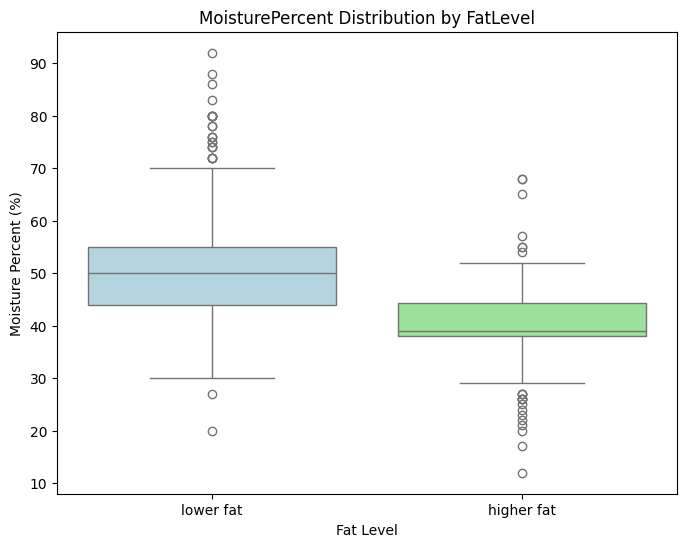

In [21]:
# Box Plot of MoisturePercent by FatLevel
plt.figure(figsize=(8, 6))
sns.boxplot(x='FatLevel', y='MoisturePercent', data=cheese_df,
            order=['lower fat', 'higher fat'], palette =['lightblue','lightgreen'])
plt.title("MoisturePercent Distribution by FatLevel")
plt.xlabel("Fat Level")
plt.ylabel("Moisture Percent (%)")
plt.show()

**A clear difference in MoisturePercent distributions between 'higher fat' and 'lower fat' validates why it is included in the model and it highlights the outliers in MoisturePercent**

### Visualization 1.2

In [22]:
# Missing values count
missing_values = train_df.isnull().sum()
print("Sum of missing values:")
print(missing_values)

Sum of missing values:
CheeseId                  0
ManufacturerProvCode      0
ManufacturingTypeEn       0
MoisturePercent          10
FlavourEn               184
CharacteristicsEn       319
Organic                   0
CategoryTypeEn           19
MilkTypeEn                1
MilkTreatmentTypeEn      54
RindTypeEn              250
CheeseName                0
FatLevel                  0
dtype: int64


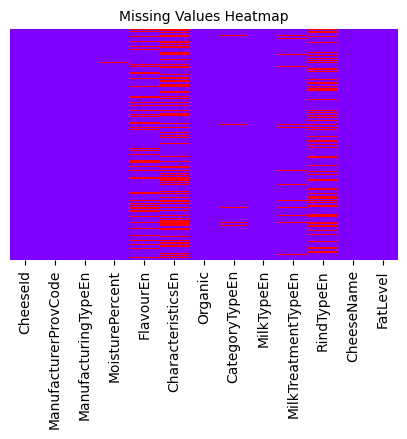

In [23]:
#Heatmap
plt.figure(figsize=(5, 3))# Set figure size
sns.heatmap(train_df.isnull(), cmap="rainbow", cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap", fontsize=10)
plt.show()

**The dataset has missing values in multiple columns, with CharacteristicsEn (319 missing values) and FlavourEn (184 missing values) being the most affected.**

### Visualization 1.3

In [24]:
# Display unique values in the FatLevel column to confirm classification categories
train_df["FatLevel"].unique()

array(['lower fat', 'higher fat'], dtype=object)

In [25]:
# Calculate the distribution of FatLevel to assess class balance
distribution = train_df["FatLevel"].value_counts()
distribution

,count
FatLevel,
lower fat,546
higher fat,287


/tmp/ipykernel_1625/3874683862.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FatLevel', data=train_df, order=['lower fat', 'higher fat'], palette=['lightblue', 'lightgreen'])


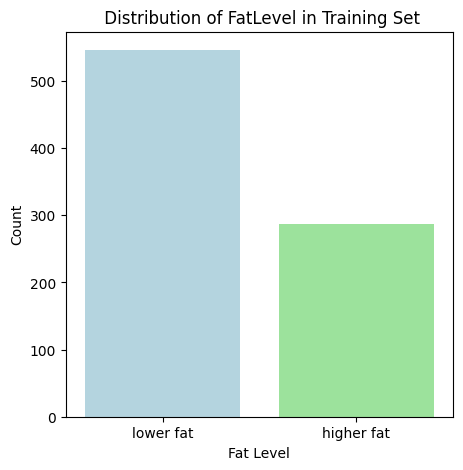

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
sns.countplot(x='FatLevel', data=train_df, order=['lower fat', 'higher fat'], palette=['lightblue', 'lightgreen'])
plt.title(" Distribution of FatLevel in Training Set")
plt.xlabel("Fat Level")
plt.ylabel("Count")
plt.show()

**The target variable is imbalanced, with ‘lower fat’ being the dominant class, as shown in the distribution. To address this, I will use class_weight='balanced' and apply SMOTE (Synthetic Minority Over-sampling Technique) to improve classification performance when using KNN.**

### Preprocessing and building pipelines

In [27]:
# Create feature and labels(X_train, y_train, X_test, y_test)
X_train = train_df.drop(columns=['FatLevel'])
y_train = train_df['FatLevel']
X_test = test_df.drop(columns=['FatLevel'])
y_test = test_df['FatLevel']

# Check the shapes of the datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (833, 12)
X_test shape: (209, 12)


**Need to encode the target variable; otherwise, the metrics will fail because they can't determine which label should be treated as the "positive" class.**

In [28]:
# Encode target
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [29]:
#Overview of X_train
X_train.head()

,CheeseId,ManufacturerProvCode,ManufacturingTypeEn,MoisturePercent,FlavourEn,CharacteristicsEn,Organic,CategoryTypeEn,MilkTypeEn,MilkTreatmentTypeEn,RindTypeEn,CheeseName
110,940,ON,Industrial,52.0,Tangy,Golden yellow,0,Semi-soft Cheese,Cow,Pasteurized,NaN,Vaquinha (Portuguese)
762,1873,ON,Industrial,40.0,Slightly more salty taste and firmer texture t...,NaN,0,Firm Cheese,Cow,Pasteurized,NaN,Gorgonzola (Castello)
898,2057,QC,Artisan,48.0,NaN,NaN,0,Semi-soft Cheese,Cow,Pasteurized,NaN,Tête à Papineau
260,1280,QC,Industrial,55.0,"Creamy flavor, hazelnut and flowery hints","Fully ripened, washed rind cheese",0,Soft Cheese,Cow,Raw Milk,Washed Rind,Petit Rubis (Le)
223,1229,QC,Artisan,60.0,"Available plain or seasoned with chives, prove...","Creamy and white cheese, ball-shaped",0,Fresh Cheese,Goat,Pasteurized,No Rind,Petites Soeurs (Les)


### Methods & Results:

In [30]:
# Define features
numeric_feats = ['MoisturePercent']
binary_feats = ['Organic']
categorical_feats = ['ManufacturerProvCode' , 'ManufacturingTypeEn',
                     'CategoryTypeEn', 'MilkTypeEn', 'MilkTreatmentTypeEn']
text_feats_flav = ['FlavourEn']
text_feats_char = ['CharacteristicsEn']

**I dropped CheeseName because it has many unique values (e.g., 500 unique names in the training set, as shown by train_df.describe()), making it impractical to vectorize, and the project instructions allow dropping it to simplify the analysis. However, I kept FlavourEn and CharacteristicsEn since they may correlate with FatLevel . Vectorizing these text features using CountVectorizer could capture these patterns and improve the model’s accuracy.**

In [31]:
# Define preprocessing transformers for numeric, categorical, binary, and text features

numeric_transformer = make_pipeline(
    SimpleImputer(strategy='median'),  # Impute missing values with median
    StandardScaler()                    # Scale numeric features
)

categorical_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),  # Impute missing values with most frequent category
    OneHotEncoder(dtype=int, handle_unknown='ignore')  # One-hot encode categorical features
)

binary_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),  # Impute missing values with most frequent category
    OneHotEncoder(dtype=int, drop='if_binary')  # One-hot encode binary features, dropping one column if binary
)

# Text transformers: Keep 2D until after imputation
text_transformer_flavour = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='missing'),  # Expects 2D
    FunctionTransformer(lambda X: X.ravel()),  # Flatten to 1D for CountVectorizer
    CountVectorizer(max_features=50, min_df=2, ngram_range=(1, 2))
)
text_transformer_char = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='missing'),  # Expects 2D
    FunctionTransformer(lambda X: X.ravel()),  # Flatten to 1D for CountVectorizer
    CountVectorizer(max_features=50, min_df=2, ngram_range=(1, 2))
)

**To organize the features for preprocessing, I used numeric_feats to hold the numeric variable MoisturePercent, binary_feats for the binary feature Organic , and categorical_feats for categorical variables ManufacturerProvCode, ManufacturingTypeEn, CategoryTypeEn, MilkTypeEn, and MilkTreatmentTypeEn. These features will be transformed using StandardScaler for numeric_feats, OneHotEncoder for categorical_feats, and CountVectorizer for FlavourEn and CharacteristicsEn.**

**I tuned CountVectorizer with max_features=50, min_df=2, and ngram_range=(1, 2) to focus on frequent, meaningful text patterns.**

In [32]:
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_feats),
    (categorical_transformer, categorical_feats),
    (binary_transformer, binary_feats),
    (text_transformer_flavour,text_feats_flav),
    (text_transformer_char,text_feats_char)
)

# Verify preprocessor configuration and feature transformation
preprocessor

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['MoisturePercent']),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(dtype=<class 'int'>,
                                                                handle_unknown='ignore'))]),
                                 ['Manufactur...
                                                  CountVectorizer(max_features=50,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2)))]),
                                 ['FlavourEn']),
                                ('pipeline-5',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('functiontransformer',
                                                  FunctionTransformer(func=<function <lambda> at 0x7cdf8ccaeac0>)),
                                                 ('countvectorizer',
                                                  CountVectorizer(max_features=50,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2)))]),
                                 ['CharacteristicsEn'])])

**I used make_pipeline and make_column_transformer to implement the preprocessing steps for simplicity**

In [33]:
# Define models

# Model 1: Random Forest with balanced class weights
main_pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=77, n_estimators=100, class_weight='balanced'))
])

# Model 2: Logistic Regression for interpretable classification
main_pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=77, class_weight='balanced'))
])

# Model 3: Support Vector Classifier for robust boundary separation
main_pipe_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(random_state=77, class_weight='balanced'))
])

# Model 4: K-Nearest Neighbors with SMOTE
main_pipe_knn = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=123)), # use smote to handle data inbalance
    ('model', KNeighborsClassifier())
])

### Reason for model selection

1. DummyClassifier was used as the baseline to reflect the majority class prediction in an imbalanced dataset, providing a simple benchmark for comparison.
2. Random Forest was chosen for its robustness and ability to capture non-linear patterns in text features.
3. Logistic Regression was selected for its interpretability and linear approach
4. SVM was evaluated for its capacity to handle non-linear relationships.
5. KNN was included to evaluate a distance-based approach, as it can capture local patterns in the data

#### Basline model using dummy classifier

In [34]:
# create a dummy classifier
dummy_clf = DummyClassifier(strategy="stratified",
                            random_state=77) # Used strategy "stratefied" to preserve class proportions and randomness
scoring_metrics = ['accuracy', 'f1', 'recall', 'precision']
dummy = cross_validate(dummy_clf,X_train, y_train_encoded, cv=5,
                       scoring = scoring_metrics,
                       return_train_score=True
                       )
dummy_scores = pd.DataFrame(dummy)
dummy_mean = dummy_scores.mean()
dummy_mean

,0
fit_time,0.001161
score_time,0.008121
test_accuracy,0.553293
train_accuracy,0.550424
test_f1,0.672517
train_f1,0.663372
test_recall,0.699600
train_recall,0.675823
test_precision,0.647458
train_precision,0.651372


In [35]:
# Random Forest
rf_scores = cross_validate(
    main_pipe_rf, X_train, y_train_encoded, cv=5, scoring=scoring_metrics,return_train_score=True)
scores_df = pd.DataFrame(rf_scores)
rf_mean = scores_df.mean()
rf_mean

,0
fit_time,0.396595
score_time,0.037901
test_accuracy,0.828266
train_accuracy,0.990095
test_f1,0.874590
train_f1,0.992396
test_recall,0.913878
train_recall,0.986267
test_precision,0.838715
train_precision,0.998624


In [36]:
# Logistic Regression
lr_scores = cross_validate(
    main_pipe_lr, X_train, y_train_encoded, cv=5,scoring=scoring_metrics, return_train_score=True)
lr_scores = pd.DataFrame(lr_scores)
lr_mean = lr_scores.mean()
lr_mean

,0
fit_time,0.109052
score_time,0.048873
test_accuracy,0.752666
train_accuracy,0.832827
test_f1,0.799331
train_f1,0.866846
test_recall,0.758165
train_recall,0.830583
test_precision,0.849132
train_precision,0.906496


In [37]:
 # Support Vector Classifier
svc_scores = cross_validate(
    main_pipe_svc, X_train, y_train_encoded,cv=5,scoring=scoring_metrics, return_train_score=True)

svc_scores = pd.DataFrame(svc_scores)
svc_mean = svc_scores.mean()
svc_mean

,0
fit_time,0.128146
score_time,0.050719
test_accuracy,0.785052
train_accuracy,0.887753
test_f1,0.829225
train_f1,0.910841
test_recall,0.802168
train_recall,0.874998
test_precision,0.861792
train_precision,0.949883


In [38]:
 # K-Nearest Neighbors
knn_scores = cross_validate(
    main_pipe_knn, X_train, y_train_encoded,cv=5,scoring=scoring_metrics, return_train_score=True)

knn_scores = pd.DataFrame(knn_scores)
knn_mean = knn_scores.mean()
knn_mean

,0
fit_time,0.084107
score_time,0.050653
test_accuracy,0.705858
train_accuracy,0.803124
test_f1,0.746730
train_f1,0.831831
test_recall,0.666622
train_recall,0.743143
test_precision,0.851868
train_precision,0.944778


In [39]:
# DataFrame for model peformance :

model_comparison_df = pd.DataFrame({
    'Dummy Classifier': dummy_mean,
    'Random Forest': rf_mean,
    'Logistic Regression': lr_mean,
    'SVC': svc_mean,
    'Knn':knn_mean,
})

model_comparison_df

,Dummy Classifier,Random Forest,Logistic Regression,SVC,Knn
fit_time,0.001161,0.396595,0.109052,0.128146,0.084107
score_time,0.008121,0.037901,0.048873,0.050719,0.050653
test_accuracy,0.553293,0.828266,0.752666,0.785052,0.705858
train_accuracy,0.550424,0.990095,0.832827,0.887753,0.803124
test_f1,0.672517,0.874590,0.799331,0.829225,0.746730
train_f1,0.663372,0.992396,0.866846,0.910841,0.831831
test_recall,0.699600,0.913878,0.758165,0.802168,0.666622
train_recall,0.675823,0.986267,0.830583,0.874998,0.743143
test_precision,0.647458,0.838715,0.849132,0.861792,0.851868
train_precision,0.651372,0.998624,0.906496,0.949883,0.944778


### Visualization 1.4

In [40]:
# Chart for model performance
model_comparison_long = model_comparison_df.mean().reset_index()
model_comparison_long.columns = ["Model", "Performance Score"]

# Create the bar chart using Altair
chart = alt.Chart(model_comparison_long).mark_bar(color="steelblue").encode(
    x=alt.X("Model:N", sort="-y", title="Model"),
    y=alt.Y("Performance Score:Q", title="Performance Score"),
    tooltip=["Model", "Performance Score"]
).properties(
    title="Model Performance Comparison",
    width=400,
    height=300
)

# Display the chart
chart

alt.Chart(...)

I chose `RandomizedSearchCV` over `GridSearchCV` for tuning SVC because it efficiently explores a large hyperparameter space in a limited time, which is suitable for a model with multiple impactful parameters.

In [41]:
# Define the parameter distribution for SVC
param_dist = {
    "model__C": scipy.stats.loguniform(0.1, 100),
    "model__gamma": scipy.stats.loguniform(1e-4, 1e-1),
    "model__kernel": ['linear', 'rbf']  # Tune kernels
}
# Set up RandomizedSearchCV with the pipeline
random_search = RandomizedSearchCV(
    main_pipe_svc,
    param_dist,
    n_iter=50,
    cv=5,
    verbose=1,
    n_jobs=-1,
    scoring="f1",
    random_state=123,
)
random_search.fit(X_train, y_train_encoded)

print("Best params:", random_search.best_params_)
print("Best F1 Score:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__C': np.float64(57.17029099720493), 'model__gamma': np.float64(0.09613239440121599), 'model__kernel': 'rbf'}
Best F1 Score: 0.8312718188351005


**After evaluating five models, Dummy Classifier, Random Forest, Logistic Regression, SVC, and KNN—for predicting cheese fat content, the SVC model emerged as the optimal choice for hyperparameter tuning. While Random Forest achieved the highest test F1-score (0.8724), it suffered from severe overfitting (train-test gap: 0.1200) and slower training times. In contrast, SVC delivered strong, balanced performance (test F1: 0.8289, precision: 0.8632) with moderate overfitting (gap: 0.0819) and faster training (0.0677s). Its ability to handle non-linear relationships via kernel functions (e.g., RBF) makes it particularly suitable for this imbalanced dataset. KNN, despite tuning, had poor recall (0.6465), while Logistic Regression underperformed in F1-score (0.8049). Thus, SVC was selected for RandomizedSearchCV to further optimize its generalization and predictive power.**

In [42]:
# tuned model from RandomizedSearchCV
best_svc = random_search.best_estimator_
# Fit the tuned model
best_svc.fit(X_train, y_train_encoded)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['MoisturePercent']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(dtype=<class 'int'>,
                                                                                 handle_u...
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(func=<function <lambda> at 0x7cdf8ccaeac0>)),
                                                                  ('countvectorizer',
                                                                   CountVectorizer(max_features=50,
                                                                                   min_df=2,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                                                  ['CharacteristicsEn'])])),
                ('model',
                 SVC(C=np.float64(57.17029099720493), class_weight='balanced',
                     gamma=np.float64(0.09613239440121599), random_state=77))])

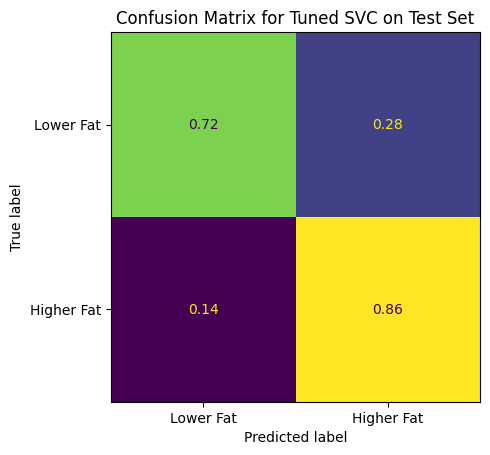

In [43]:
# Normalized confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(
    best_svc,
    X_test,
    y_test_encoded,
    normalize="true",
    display_labels=[ "Lower Fat", "Higher Fat"],
    colorbar=False,
);
plt.title("Confusion Matrix for Tuned SVC on Test Set")
plt.show()

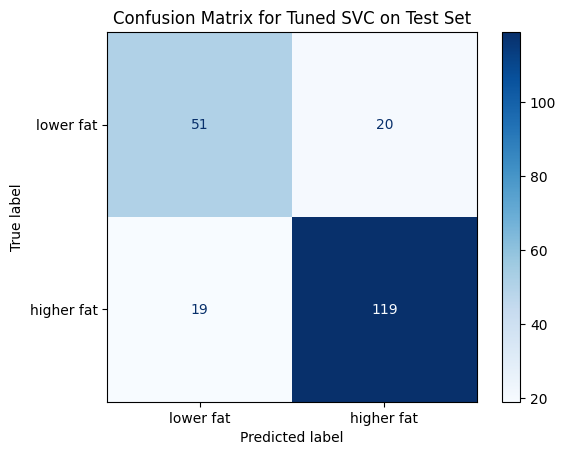

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred = best_svc.predict(X_test)
cm = confusion_matrix(y_test_encoded, y_pred, labels=best_svc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['lower fat', 'higher fat'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Tuned SVC on Test Set")
plt.show()

In [45]:
# Classification report

report = classification_report(y_test_encoded, best_svc.predict(X_test),
                               target_names=["lower fat", "higher fat"],output_dict=True)
report_df = pd.DataFrame(report)
report_df

,lower fat,higher fat,accuracy,macro avg,weighted avg
precision,0.728571,0.856115,0.813397,0.792343,0.812787
recall,0.718310,0.862319,0.813397,0.790314,0.813397
f1-score,0.723404,0.859206,0.813397,0.791305,0.813072
support,71.000000,138.000000,0.813397,209.000000,209.000000


### Conclusion

The tuned SVC model achieved an accuracy of 0.8134 on the test set, with a weighted F1-score of 0.8131, outperforming the baseline DummyClassifier (test F1=0.6725) by 0.1406 in weighted F1-score. It performed better on the majority class, higher fat (F1=0.8592, precision=0.8561, recall=0.8623), than on lower fat (F1=0.7234, precision=0.7286, recall=0.7183), reflecting the dataset’s imbalance (138 higher fat vs. 71 lower fat samples). The macro F1-score of 0.7913 indicates balanced performance across classes despite the imbalance. Overall, SVC provides a robust solution for predicting cheese fat levels, though future improvements could involve addressing the class imbalance with techniques like SMOTE to enhance performance on the minority class.

### Questions to explore
Can we predict the CategoryTypeEn of a cheese based on its features? Predicting cheese category can help manufacturers classify new cheeses or understand what features define a category.

### Expectation

I expected the RandomForest model to perform better, but it ultimately overfit the training data. The inclusion of text-based features may have contributed to this performance issue by introducing noise or overly complex patterns that didn't generalize well to unseen data.

## Attributions
- Canadian Cheese Directory- [kaggle](https://www.kaggle.com/datasets/noahjanes/canadian-cheese-directory/data)

## Reources
- [github](https://bait509-ubc.github.io/BAIT509/lectures/lecture9.html)
- Lecture note and Assignment
